# Descripción del proyecto

## Contexto:
Eres analista en una gran tienda online. Junto con el departamento de marketing has recopilado una lista de hipótesis que pueden ayudar a aumentar los ingresos.

Tienes que priorizar estas hipótesis, lanzar un test A/B y analizar los resultados.

# Parte 1. Priorizar hipótesis

## 1.1 Exploración de los datos

In [1]:
# Importar las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Crear data frames para los archivos csv
hipotesis_df = pd.read_csv('/datasets/hypotheses_us.csv', sep = ';')
ordenes_df = pd.read_csv('/datasets/orders_us.csv')
visitas_df = pd.read_csv('/datasets/visits_us.csv')

In [3]:
# Ver el dataframe
hipotesis_df

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


In [4]:
#Ver el dataframe
ordenes_df

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
...,...,...,...,...,...
1192,2662137336,3733762160,2019-08-14,100.8,B
1193,2203539145,370388673,2019-08-14,50.1,A
1194,1807773912,573423106,2019-08-14,165.3,A
1195,1947021204,1614305549,2019-08-14,5.5,A


In [5]:
# Ver el dataframe
visitas_df

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
...,...,...,...
57,2019-08-27,B,720
58,2019-08-28,B,654
59,2019-08-29,B,531
60,2019-08-30,B,490


In [6]:
# Información general
hipotesis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [7]:
# Informacióm general
ordenes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


In [8]:
# Información general
visitas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [9]:
# Convertir a formato fecha
ordenes_df['date'] = pd.to_datetime(ordenes_df['date'])

In [10]:
# Convedrtir a formato fecha
visitas_df['date'] = pd.to_datetime(visitas_df['date'])

In [11]:
# Corroborar los tipos de datos
ordenes_df.dtypes

transactionId             int64
visitorId                 int64
date             datetime64[ns]
revenue                 float64
group                    object
dtype: object

In [12]:
# Corroborar los tipos de datos
visitas_df.dtypes

date      datetime64[ns]
group             object
visits             int64
dtype: object

## 1.2 Limpieza de los datos

In [13]:
# Buscar visitantes que aparezcan tanto en el grupo A como en el grupo B
users_group_a = ordenes_df[ordenes_df['group'] == 'A']['visitorId'].unique()
users_group_b = ordenes_df[ordenes_df['group'] == 'B']['visitorId'].unique()
common_users = np.intersect1d(users_group_a, users_group_b)

print("\nNúmero de usuarios que aparecen en ambos grupos (A y B):", len(common_users))


Número de usuarios que aparecen en ambos grupos (A y B): 58


In [14]:
# Filtrar el dataframe de órdenes para eliminar los 58 visitantes que aparecen en ambos grupos.
ordenes_df_clean = ordenes_df[~ordenes_df['visitorId'].isin(common_users)]

ordenes_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1016 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1016 non-null   int64         
 1   visitorId      1016 non-null   int64         
 2   date           1016 non-null   datetime64[ns]
 3   revenue        1016 non-null   float64       
 4   group          1016 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 47.6+ KB


## 1.3 Aplicaciones de frameworks para priorizar las hipótesis

El archivo hypotheses_us.csv contiene nueve hipótesis sobre cómo aumentar los ingresos de una tienda online con Reach, Impact, Confidence y Effort especificados para cada una.

### 1.3.1 Aplicación del framework ICE

#### Framework ICE

El framework **ICE** (Impacto, Confianza, Facilidad) se utiliza para priorizar hipótesis según su potencial de impacto, la confianza en su efectividad y la facilidad de implementación. La fórmula es:

**ICE Score = Impact × Confidence × Ease**

Donde:
- **Impact**: Mide el impacto esperado en los usuarios o los ingresos (escala de 1 a 10).
- **Confidence**: Representa el nivel de confianza en la hipótesis (escala de 1 a 10).
- **Ease**: Indica la facilidad de implementación, calculada como (10 - Effort), donde Effort es el esfuerzo requerido (escala de 1 a 10).

In [15]:
# Calcular Ease como (10 - Effort)
hipotesis_df['Ease'] = 10 - hipotesis_df['Effort']

# Calcular el puntaje ICE
hipotesis_df['ICE_Score'] = hipotesis_df['Impact'] * hipotesis_df['Confidence'] * hipotesis_df['Ease']

# Ordenar las hipótesis por ICE_Score en orden descendente
hipotesis_df = hipotesis_df.sort_values(by='ICE_Score', ascending=False)

# Mostrar el resultado
hipotesis_df

,Hypothesis,Reach,Impact,Confidence,Effort,Ease,ICE_Score
8,Launch a promotion that gives users discounts ...,1,9,9,5,5,405
0,Add two new channels for attracting traffic. T...,3,10,8,6,4,320
7,Add a subscription form to all the main pages....,10,7,8,5,5,280
6,Show banners with current offers and sales on ...,5,3,8,3,7,168
2,Add product recommendation blocks to the store...,8,3,7,3,7,147
5,Add a customer review page. This will increase...,3,2,2,3,7,28
3,Change the category structure. This will incre...,8,3,3,8,2,18
4,Change the background color on the main page. ...,3,1,1,1,9,9
1,Launch your own delivery service. This will sh...,2,5,4,10,0,0


#### Observaciones:
Las hipótesis 8, 0 y 7 son las prioritarias, según el framework ICE.

### 1.3.2 Aplicación de framework RICE

#### Framework RICE

El framework **RICE** (Reach, Impact, Confidence, Effort) se utiliza para priorizar hipótesis considerando el alcance, el impacto, la confianza y el esfuerzo requerido. La fórmula es:

**RICE Score = (Reach × Impact × Confidence) / Effort**

Donde:
- **Reach**: Mide el número de usuarios afectados por la hipótesis (escala de 1 a 10).
- **Impact**: Representa el impacto esperado en los usuarios o los ingresos (escala de 1 a 10).
- **Confidence**: Indica el nivel de confianza en la hipótesis (escala de 1 a 10).
- **Effort**: Refleja los recursos necesarios para probar la hipótesis (escala de 1 a 10). A mayor esfuerzo, menor es la prioridad.

In [16]:
# Calcular el puntaje RICE
hipotesis_df['RICE_Score'] = (hipotesis_df['Reach'] * hipotesis_df['Impact'] * hipotesis_df['Confidence']) / hipotesis_df['Effort']

# Ordenar las hipótesis por RICE_Score en orden descendente
hipotesis_df = hipotesis_df.sort_values(by='RICE_Score', ascending=False)

# Mostrar el resultado
hipotesis_df

,Hypothesis,Reach,Impact,Confidence,Effort,Ease,ICE_Score,RICE_Score
7,Add a subscription form to all the main pages....,10,7,8,5,5,280,112.0
2,Add product recommendation blocks to the store...,8,3,7,3,7,147,56.0
0,Add two new channels for attracting traffic. T...,3,10,8,6,4,320,40.0
6,Show banners with current offers and sales on ...,5,3,8,3,7,168,40.0
8,Launch a promotion that gives users discounts ...,1,9,9,5,5,405,16.2
3,Change the category structure. This will incre...,8,3,3,8,2,18,9.0
5,Add a customer review page. This will increase...,3,2,2,3,7,28,4.0
1,Launch your own delivery service. This will sh...,2,5,4,10,0,0,4.0
4,Change the background color on the main page. ...,3,1,1,1,9,9,3.0


#### Observaciones:
De acuerdo con el framework RICE, las hipótesis prioritarias son las 7, 2 y 0

### 1.3.3 Comparación de priorización de hipótesis ICE vs RICE

In [17]:
# Crear tablas individuales para ICE y RICE
priorizacion_ICE = hipotesis_df[['Hypothesis', 'ICE_Score']].sort_values(by='ICE_Score', ascending=False)
priorizacion_RICE = hipotesis_df[['Hypothesis', 'RICE_Score']].sort_values(by='RICE_Score', ascending=False)


In [18]:
# Unir las tablas manteniendo ambas columnas Hypotheses
comparacion_priorizciones = pd.DataFrame({
    'Priority': range(1, len(priorizacion_ICE) + 1),
    'HypothesisID_ICE': priorizacion_ICE.index,
    'Hypothesis_ICE': priorizacion_ICE['Hypothesis'].values,
    'ICE_Score': priorizacion_ICE['ICE_Score'].values,
    'HypothesisID_RICE': priorizacion_RICE.index,
    'Hypothesis_RICE': priorizacion_RICE['Hypothesis'].values,
    'RICE_Score': priorizacion_RICE['RICE_Score'].values
})

In [19]:
# Mostrar la tabla comparativa
comparacion_priorizciones

,Priority,HypothesisID_ICE,Hypothesis_ICE,ICE_Score,HypothesisID_RICE,Hypothesis_RICE,RICE_Score
0,1,8,Launch a promotion that gives users discounts ...,405,7,Add a subscription form to all the main pages....,112.0
1,2,0,Add two new channels for attracting traffic. T...,320,2,Add product recommendation blocks to the store...,56.0
2,3,7,Add a subscription form to all the main pages....,280,0,Add two new channels for attracting traffic. T...,40.0
3,4,6,Show banners with current offers and sales on ...,168,6,Show banners with current offers and sales on ...,40.0
4,5,2,Add product recommendation blocks to the store...,147,8,Launch a promotion that gives users discounts ...,16.2
5,6,5,Add a customer review page. This will increase...,28,3,Change the category structure. This will incre...,9.0
6,7,3,Change the category structure. This will incre...,18,5,Add a customer review page. This will increase...,4.0
7,8,4,Change the background color on the main page. ...,9,1,Launch your own delivery service. This will sh...,4.0
8,9,1,Launch your own delivery service. This will sh...,0,4,Change the background color on the main page. ...,3.0


In [20]:
# Mostrar los parámetros de las hipótesis
hipotesis_df.loc[[7, 0, 8, 2], ['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort', 'Ease']]

,Hypothesis,Reach,Impact,Confidence,Effort,Ease
7,Add a subscription form to all the main pages....,10,7,8,5,5
0,Add two new channels for attracting traffic. T...,3,10,8,6,4
8,Launch a promotion that gives users discounts ...,1,9,9,5,5
2,Add product recommendation blocks to the store...,8,3,7,3,7


### Observaciones:
Las hipótesis 7 y 0 aparecen entre las tres con el uso de ambos frameworks (ICE y RICE); mientras que las hipótesis 8 y 2 entran al top 3 según el framework aplicado. Esto sucede así, por los par+ametros ocupados por cada framework. El framework ICE favorece a la hipótesis 8, por que sus parámetros de Impacto y Confianza son altos, mientras que estos mismos parámetros son menores para la hipótesis 2. Por otro lado, con el framework RICE, la hipótesis 2 se ve favorecida por los parámetros Alcance (alto) y Esfuerzo (bajo); la hipósis 8 se ve desfavorecida por su muy bajo Alcance.

Como se mencionó anteriormete, las hipótesis 7 y 0 aparacen en el top 3 de hipótesis prioritarias en ambos frameworks, porque tienen magnitudes suficientemente buenas en sus parámetros; para verse favoricidas sin importar el framework urilizado (ICE o RICE).

# Parte 2. Análisis del test A/B

## 2.1 Representar gráficamente el ingreso acumulado por grupo.

In [21]:
# Agrupar por fecha y grupo, sumando los ingresos
ingreso_por_dia = ordenes_df.groupby(['date', 'group'])['revenue'].sum().reset_index()

# Calcular ingreso acumulado por grupo
ingreso_acumulado = ingreso_por_dia.pivot(index='date', columns='group', values='revenue').fillna(0).cumsum()

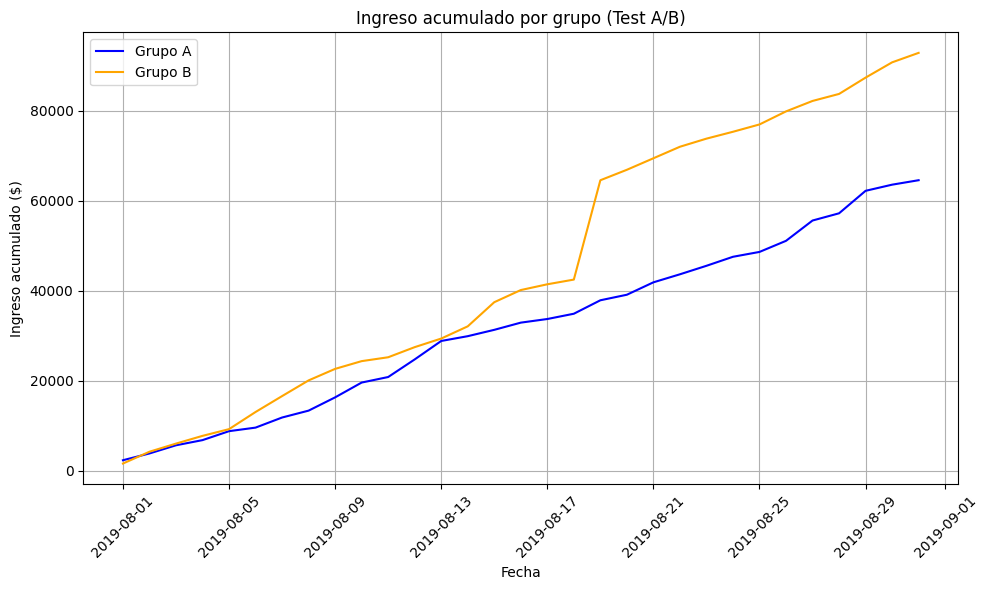

In [22]:
# Crear el gráfico de líneas
plt.figure(figsize=(10, 6))
plt.plot(ingreso_acumulado.index, ingreso_acumulado['A'], label='Grupo A', color='blue')
plt.plot(ingreso_acumulado.index, ingreso_acumulado['B'], label='Grupo B', color='orange')
plt.title('Ingreso acumulado por grupo (Test A/B)')
plt.xlabel('Fecha')
plt.ylabel('Ingreso acumulado ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observaciones:
- Los ingresos acumulados del grupo B son consistentemente mayores que los del grupo A a lo largo del tiempo.
- Cabe señalar que, luego del 17 de agosto de 2019, los ingresos del grupo B se disparan significativamente, alcanzando un pico notable, para luego estabilizarse a partir del 21 de agosto del mismo año.
- El grupo A muestra un crecimiento más gradual y constante, sin experimentar un incremento súbito comparable al del grupo B.

### Conjeturas:
- Las diferencias en la versión de la tienda en línea utilizada por el grupo B parecen estar impactando positivamente los ingresos, mostrando un mejor desempeño en comparación con la versión actual (grupo A). Esto sugiere que la variante probada en el grupo B podría ser más efectiva para aumentar los ingresos.
- El incremento vertiginoso en el grupo B alrededor del 17 de agosto de 2019 sugiere un suceso anómalo no observado en el grupo A, posiblemente debido a compras extraordinariamente grandes realizadas por algunos clientes del grupo B.
- Es posible que los usuarios del grupo B respondan mejor a la variante probada en esa versión de la tienda, mientras que la versión actual del grupo A podría estar desalentando compras o no estar resonando con los usuarios (por ejemplo, debido a un diseño menos atractivo, una promoción menos efectiva o una funcionalidad confusa).

## 2.2 Representar gráficamente el tamaño de pedido promedio acumulado por grupo.

In [23]:
# Agrupar por fecha y grupo: sumar ingresos y contar pedidos
pedidos_por_dia = ordenes_df.groupby(['date', 'group']).agg({
    'revenue': 'sum',
    'transactionId': 'count'
}).reset_index().rename(columns={'transactionId': 'num_pedidos'})

# Calcular ingreso acumulado y número de pedidos acumulado
pedidos_por_dia['ingreso_acumulado'] = pedidos_por_dia.groupby('group')['revenue'].cumsum()
pedidos_por_dia['pedidos_acumulados'] = pedidos_por_dia.groupby('group')['num_pedidos'].cumsum()

# Calcular tamaño de pedido promedio acumulado
pedidos_por_dia['avg_order_size'] = pedidos_por_dia['ingreso_acumulado'] / pedidos_por_dia['pedidos_acumulados']

# Pivotar para tener columnas por grupo
avg_order_size_acumulado = pedidos_por_dia.pivot(index='date', columns='group', values='avg_order_size').fillna(0)

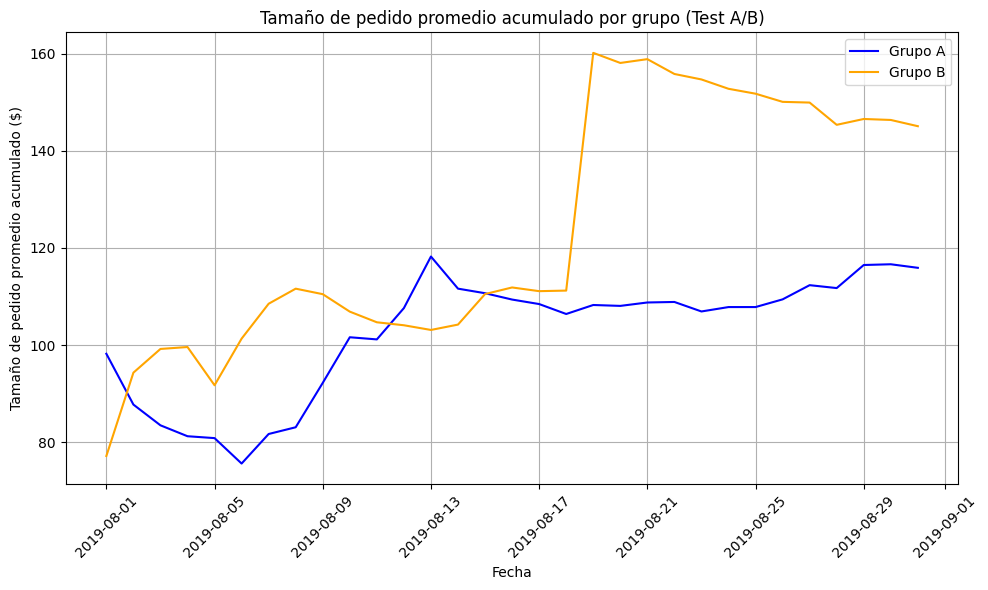

In [24]:
# Crear el gráfico de líneas
plt.figure(figsize=(10, 6))
plt.plot(avg_order_size_acumulado.index, avg_order_size_acumulado['A'], label='Grupo A', color='blue')
plt.plot(avg_order_size_acumulado.index, avg_order_size_acumulado['B'], label='Grupo B', color='orange')
plt.title('Tamaño de pedido promedio acumulado por grupo (Test A/B)')
plt.xlabel('Fecha')
plt.ylabel('Tamaño de pedido promedio acumulado ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observaciones:
- El grupo B tiende a desempeñarse mejor que el grupo A en términos de tamaño de pedido promedio acumulado durante la mayor parte del período analizado.
- El grupo A superó al grupo B en tamaño de pedido promedio acumulado solo al inicio de la prueba y brevemente antes de la mitad del período.
- Se observa un súbito incremento en el tamaño de pedido promedio acumulado del grupo B, notable alrededor del 17-21 de agosto de 2019, seguido de una estabilización a un nivel superior al del grupo A.
- El grupo A muestra un crecimiento más gradual y constante, sin experimentar un incremento súbito comparable al del grupo B.

### Conjeturas:
- El mayor tamaño de pedido promedio acumulado en el grupo B, sugiere que la variante probada en esta versión de la tienda en línea, incentiva a los usuarios a realizar compras de mayor valor en comparación con los usuarios del grupo A (versión actual).
- El incremento súbito en el tamaño de pedido promedio acumulado del grupo B, alrededor del 17-21 de agosto de 2019, podría deberse a uno o más pedidos excepcionalmente grandes realizados en ese período.
- El aumento súbito en el grupo B sugiere la presencia de valores atípicos en el ingreso que influyeron significativamente en el promedio acumulado, mientras que el grupo A no experimentó eventos similares, manteniendo un tamaño de pedido promedio más estable pero inferior.
- El hecho de que el grupo A tuviera un tamaño de pedido promedio mayor al inicio y brevemente antes de la mitad del período podría indicar que la versión actual (grupo A) inicialmente atrajo a usuarios dispuestos a realizar pedidos más grandes, pero este efecto no fue sostenido, posiblemente debido a una menor aceptación a lo largo del tiempo.

## 2.3 Representar gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A.

In [25]:
# Calcular la diferencia relativa del grupo B respecto al grupo A
# Fórmula: (Grupo B - Grupo A) / Grupo A * 100
diferencia_relativa = ((avg_order_size_acumulado['B'] - avg_order_size_acumulado['A']) / avg_order_size_acumulado['A']) * 100

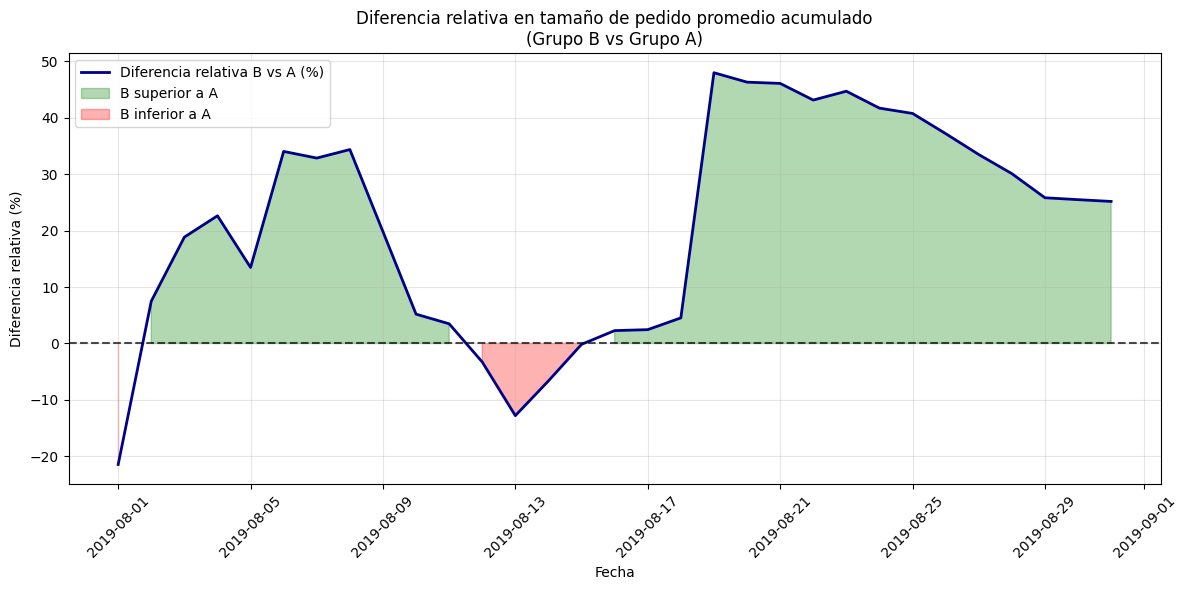

In [26]:
# Crear el gráfico de diferencia relativa
plt.figure(figsize=(12, 6))
colors = ['green' if x >= 0 else 'red' for x in diferencia_relativa.values]
plt.plot(diferencia_relativa.index, diferencia_relativa.values, 
         color='darkblue', linewidth=2, label='Diferencia relativa B vs A (%)')
plt.fill_between(diferencia_relativa.index, diferencia_relativa.values, 0, 
                 where=(diferencia_relativa.values >= 0), color='green', alpha=0.3, label='B superior a A')
plt.fill_between(diferencia_relativa.index, diferencia_relativa.values, 0, 
                 where=(diferencia_relativa.values < 0), color='red', alpha=0.3, label='B inferior a A')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
plt.title('Diferencia relativa en tamaño de pedido promedio acumulado\n(Grupo B vs Grupo A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observaciones:
- La diferencia relativa en el tamaño promedio del pedido, corrobora que el grupo B se desempoñó mucho mejor que el grupo A, dado que la diferencia relativa es positiva durante la mayor parte del tiempo de la prueba.
- Sólo hay dos periodo cortos, 1ro de agosto del 2019 y del 10 al 15 de agosto del mismo año, en los que la diferencia relativa tiene valores negativos, lo que indica que el grupo A tuvo un mejor desempeño que el grupo B en esos intervalos.
- La segunda mitad de la prueba muestra que la diferencia relativa (positiva) fue aún más pronunciada.

### Conjeturas:
- La tendencia positiva en la diferencia relativa, sugiere que la variante probada en el grupo B incentiva compras de mayor valor de manera más efectiva que la versión actual del grupo A, lo que podría indicar una aceptación generalizada de la variante B por parte de los usuarios.
- Los períodos con diferencia negativa (1 de agosto y 10-15 de agosto de 2019) podrían reflejar momentos en los que la versión actual del grupo A atrajo a usuarios con mayor disposición a realizar pedidos más grandes, posiblemente debido a una preferencia inicial por la configuración existente o a un evento específico que favoreció al grupo A.
- El hecho de que la diferencia relativa se haya incrementado a mediados de agosto, podría estar influenciado por un evento anómalo en el grupo B, que incrementó significativamente el tamaño de pedido promedio acumulado y consolidó su ventaja.
- La transición de períodos negativos a positivos en la diferencia relativa podría indicar que los usuarios tardaron en adaptarse a la variante del grupo B, pero una vez aceptada (después del 15 de agosto), esta versión comenzó a generar pedidos de mayor valor de forma sostenida.

## 2.4 Calcular la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. Representar gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia.

In [27]:
# Combinar pedidos_por_dia con visitas_df
conversion_data = pd.merge(visitas_df, pedidos_por_dia, 
                          on=['date', 'group'], 
                          how='left')

# Llenar valores NaN con 0 (días sin pedidos)
conversion_data['num_pedidos'] = conversion_data['num_pedidos'].fillna(0)

In [28]:
# Calcular tasa de conversión = pedidos / visitas
conversion_data['conversion_rate'] = conversion_data['num_pedidos'] / conversion_data['visits']

# Convertir a porcentaje (opcional)
conversion_data['conversion_rate_pct'] = conversion_data['conversion_rate'] * 100

In [29]:
# Mostrar los resultados
conversion_data

,date,group,visits,revenue,num_pedidos,ingreso_acumulado,pedidos_acumulados,avg_order_size,conversion_rate,conversion_rate_pct
0,2019-08-01,A,719,2356.8,24,2356.8,24,98.200000,0.033380,3.337969
1,2019-08-02,A,619,1503.5,20,3860.3,44,87.734091,0.032310,3.231018
2,2019-08-03,A,507,1815.2,24,5675.5,68,83.463235,0.047337,4.733728
3,2019-08-04,A,717,1146.6,16,6822.1,84,81.215476,0.022315,2.231520
4,2019-08-05,A,756,1988.1,25,8810.2,109,80.827523,0.033069,3.306878
...,...,...,...,...,...,...,...,...,...,...
57,2019-08-27,B,720,2319.8,16,82161.3,548,149.929380,0.022222,2.222222
58,2019-08-28,B,654,1558.0,28,83719.3,576,145.346007,0.042813,4.281346
59,2019-08-29,B,531,3623.7,20,87343.0,596,146.548658,0.037665,3.766478
60,2019-08-30,B,490,3393.3,24,90736.3,620,146.348871,0.048980,4.897959


In [30]:
# Estadísticas básicas por grupo
print("\nEstadísticas de tasa de conversión por grupo:")
print(conversion_data.groupby('group')['conversion_rate_pct'].describe())


Estadísticas de tasa de conversión por grupo:
       count      mean      std       min       25%       50%       75%  \
group                                                                     
A       31.0  3.065067  0.98951  1.610306  2.316716  2.795031  3.805147   
B       31.0  3.525747  1.12643  1.221167  2.766384  3.571429  4.234266   

            max  
group            
A      5.341880  
B      6.233062  


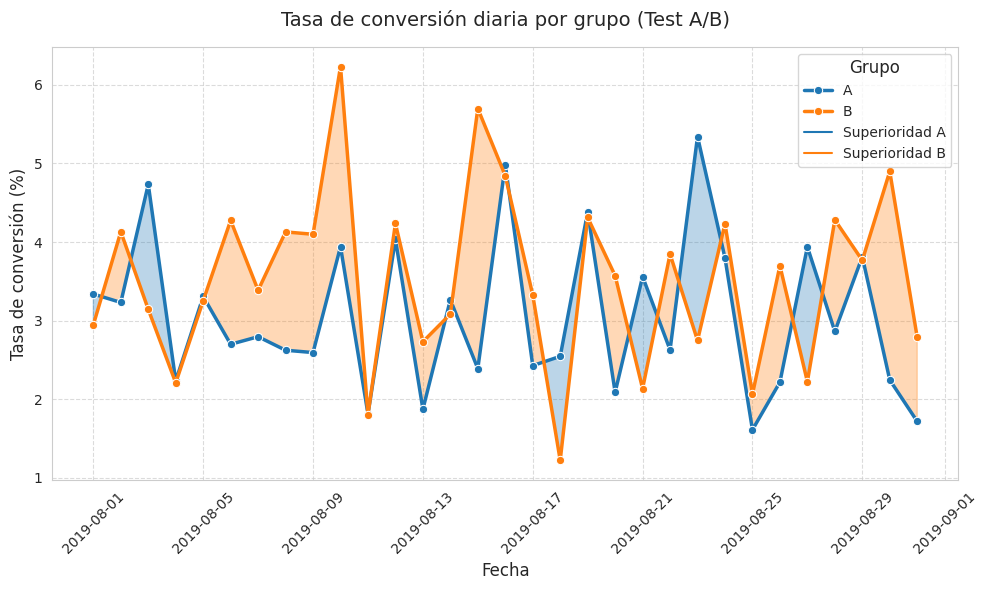

In [31]:
# Configurar estilo de seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Crear el gráfico de líneas con seaborn
sns.lineplot(data=conversion_data, x='date', y='conversion_rate_pct', hue='group', 
             palette=['#1f77b4', '#ff7f0e'], linewidth=2.5, marker='o')

# Extraer datos para fill_between
dates = conversion_data[conversion_data['group'] == 'A']['date'].values
rate_a = conversion_data[conversion_data['group'] == 'A']['conversion_rate_pct'].values
rate_b = conversion_data[conversion_data['group'] == 'B']['conversion_rate_pct'].values

# Rellenar áreas entre las líneas
plt.fill_between(dates, rate_a, rate_b, where=(rate_b > rate_a), 
                 interpolate=True, color='#ff7f0e', alpha=0.3, label='Superioridad B')
plt.fill_between(dates, rate_a, rate_b, where=(rate_a > rate_b), 
                 interpolate=True, color='#1f77b4', alpha=0.3, label='Superioridad A')

# Personalizar el gráfico
plt.title('Tasa de conversión diaria por grupo (Test A/B)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Tasa de conversión (%)', fontsize=12)
plt.legend(title='Grupo', title_fontsize=12, labels=['A', 'B', 'Superioridad A', 'Superioridad B'])
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

### Observaciones:
- Con base en la descripción estadística de las tasas de conversión, de ambos grupos, no parece haber una gran diferencia. En promedio, la tasa del grupo B es menos de 0.05% superior a la del grupo A (3.52% y 3.06% respectivamente).
- La misma situación se observa en los percentiles, es decir, diferencia menores al 0.05%
- Atendiendo el gráfico de líneas, se observa que las tasas de conversión de ambos grupos; fluctúa a lo largo del tiempo. No obstante, hay un clara superioridad en la tasa del grupo B con respecto a la tasa del grupo A.
- Hay periodos puntuales, en los que el grupo A se desempeñó mejor.

### Conjeturas:
- La pequeña diferencia promedio (menos de 0.05%) entre las tasas de conversión del grupo B y el grupo A sugiere que la variante probada en el grupo B tiene un impacto limitado pero positivo, lo que podría indicar una leve mejora en la conversión que no se traduce en una ventaja significativa en términos absolutos.
- La superioridad de la tasa de conversión del grupo B, en periodos relativamente largos, indican que la versión de la tienda probada por estos usurios, se vieron más incentivados a hacer compras que aquellos usuarios del grupo A.
- La fluctuación observada y la tendencia general de superioridad del grupo B podrían reflejar un proceso de adaptación de los usuarios a la variante, donde las conversiones favorecen puntualmente al grupo A. Sin embargo, luego la variante B gana tracción, resultando en una mayor tasa de conversión a lo largo del tiempo.

## 2.5 Traza un gráfico de dispersión del número de pedidos por usuario.

In [32]:
# Contar el número de pedidos por usuario y grupo
pedidos_por_usuario = ordenes_df.groupby(['visitorId', 'group'])['transactionId'].count().reset_index()
pedidos_por_usuario = pedidos_por_usuario.rename(columns={'transactionId': 'num_pedidos'})

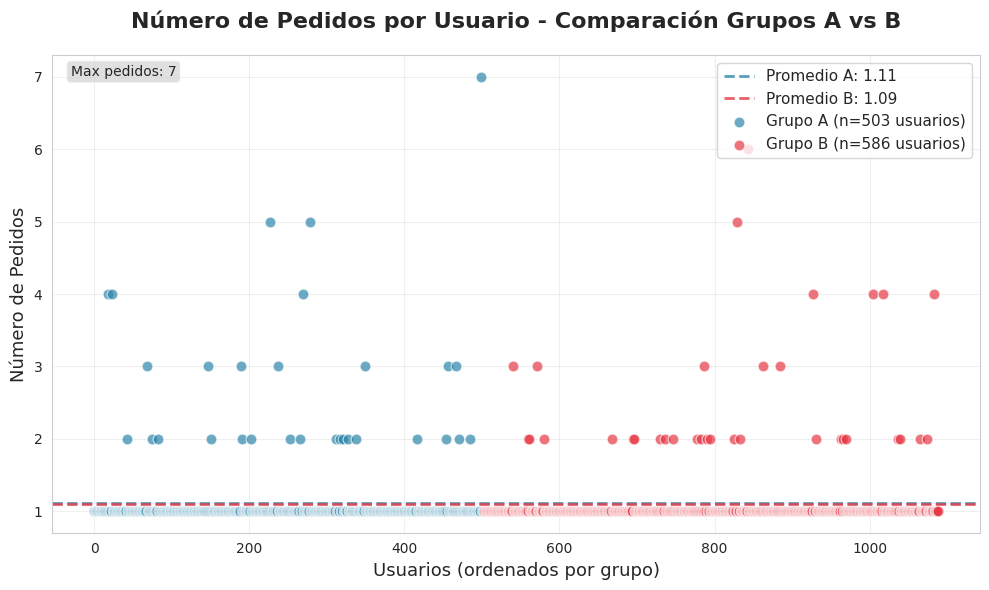

In [33]:
# Configurar el estilo
plt.figure(figsize=(10, 6))

# Separar datos por grupo
grupo_a = pedidos_por_usuario[pedidos_por_usuario['group'] == 'A']
grupo_b = pedidos_por_usuario[pedidos_por_usuario['group'] == 'B']

# Crear índices para el eje x (posición de cada usuario)
x_a = range(len(grupo_a))
x_b = range(len(grupo_a), len(grupo_a) + len(grupo_b))

# Crear el gráfico de dispersión
plt.scatter(x_a, grupo_a['num_pedidos'], alpha=0.7, s=60, 
           color='#2E86AB', label=f'Grupo A (n={len(grupo_a)} usuarios)', 
           edgecolors='white', linewidth=0.8)
plt.scatter(x_b, grupo_b['num_pedidos'], alpha=0.7, s=60, 
           color='#E63946', label=f'Grupo B (n={len(grupo_b)} usuarios)', 
           edgecolors='white', linewidth=0.8)

# Añadir líneas de promedio
plt.axhline(y=grupo_a['num_pedidos'].mean(), color='#2E86AB', 
           linestyle='--', alpha=0.8, linewidth=2, 
           label=f'Promedio A: {grupo_a["num_pedidos"].mean():.2f}')
plt.axhline(y=grupo_b['num_pedidos'].mean(), color='#E63946', 
           linestyle='--', alpha=0.8, linewidth=2, 
           label=f'Promedio B: {grupo_b["num_pedidos"].mean():.2f}')

# Personalizar el gráfico
plt.title('Número de Pedidos por Usuario - Comparación Grupos A vs B', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Usuarios (ordenados por grupo)', fontsize=13)
plt.ylabel('Número de Pedidos', fontsize=13)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Mostrar estadísticas en el gráfico
plt.text(0.02, 0.98, f'Max pedidos: {pedidos_por_usuario["num_pedidos"].max()}', 
         transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7),
         verticalalignment='top')

plt.show()

### Observaciones:
- El número de pedidos por usuario es prácticamente igual, sin importar la versión de la tienda (grupo A o grupo B). Lo que se corrobora con el promedio de pedidos por usuario y por grupo, siendo de 1.11 pedidos para el grupo A y 1.09 para el grupo B.

### Conjeturas:
- La similitud en el número de pedidos por usuario entre el grupo A y el grupo B, con promedios tan cercanos (1.11 vs. 1.09), sugiere que la variante probada en el grupo B no ha logrado incentivar significativamente a los usuarios a realizar más pedidos en comparación con la versión actual del grupo A.
- El promedio ligeramente menor de pedidos en el grupo B (1.09 vs. 1.11) podría indicar que la versión de la tienda probada en este grupo tiene un efecto sutilmente negativo o neutral en la repetición de compras.
- La similitud en los promedios bajos (alrededor de 1 pedido por usuario) podría reflejar que la mayoría de los usuarios en ambos grupos son compradores ocasionales, y ni la versión actual ni la variante han sido efectivas para convertirlos en clientes recurrentes.

## 2.6 Calcular los percentiles 95 y 99 del número de pedidos por usuario. Definir el punto en el cual un punto de datos se convierte en una anomalía.

In [34]:
# Calcular los percentiles 95 y 99 del número de pedidos por usuario
percentiles = pedidos_por_usuario['num_pedidos'].quantile([0.95, 0.99])
percentil_95 = percentiles[0.95]
percentil_99 = percentiles[0.99]

print(f"Percentil 95: {percentil_95}")
print(f"Percentil 99: {percentil_99}")

# Definir el punto de anomalía
punto_anomalia = percentil_99
print(f"El punto en el que un punto de datos se convierte en una anomalía es: {punto_anomalia} pedidos por usuario.")

Percentil 95: 2.0
Percentil 99: 4.0
El punto en el que un punto de datos se convierte en una anomalía es: 4.0 pedidos por usuario.


## 2.7 Trazar un gráfico de dispersión de los precios de los pedidos.

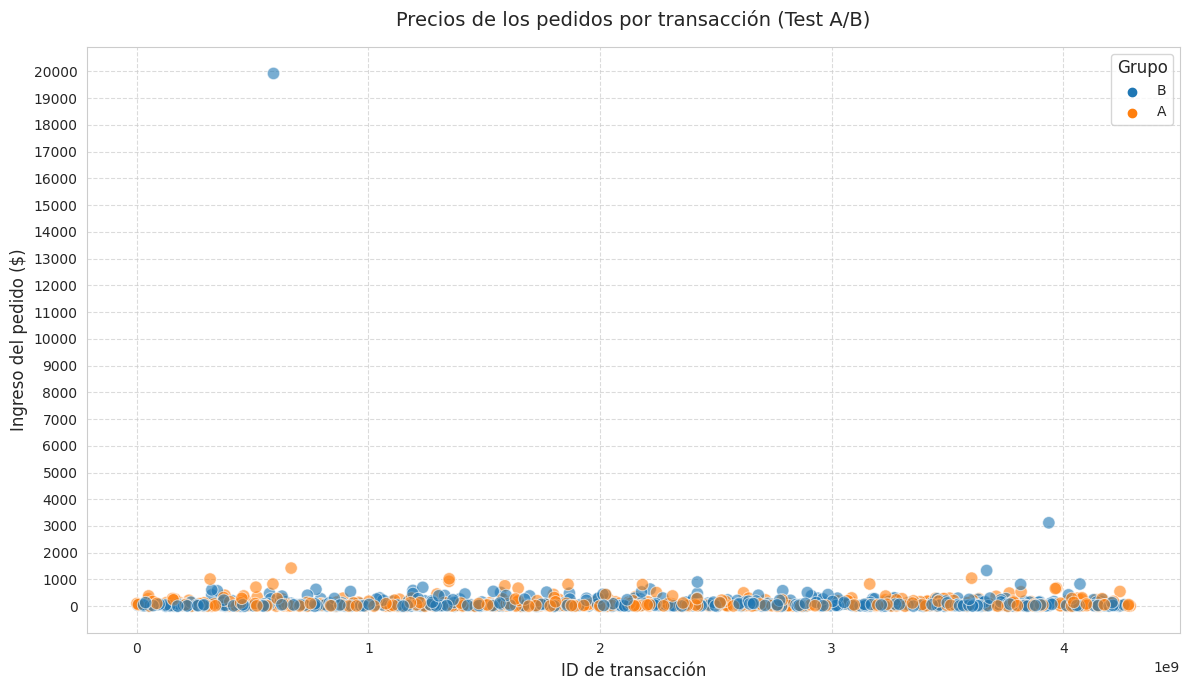

In [35]:
# Configurar estilo de seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

# Crear el gráfico de dispersión con seaborn, diferenciando por grupo
sns.scatterplot(data=ordenes_df_clean, x='transactionId', y='revenue', hue='group', 
                palette=['#1f77b4', '#ff7f0e'], alpha=0.6, s=80)

# Personalizar el gráfico
plt.title('Precios de los pedidos por transacción (Test A/B)', fontsize=14, pad=15)
plt.xlabel('ID de transacción', fontsize=12)
plt.ylabel('Ingreso del pedido ($)', fontsize=12)
plt.legend(title='Grupo', title_fontsize=12) 
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustar intervalos del eje Y a incrementos de 1000
plt.yticks(range(0, int(ordenes_df_clean['revenue'].max()) + 1000, 1000))

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

### Observaciones:
- Las dispersiones de ambos grupos, se aglutinan menos de 2000 dólares por pedido, sun una clara dominancia por parte de algún grupo.
- Sin embargo, hay un par de valores atípicos que superan por mucho los 2000 USD; uno de más de 3000 USD y otro de hasta 20000 USD. Ambos pertenenciendo al grupo B.

### Conjeturas:
- El hecho de que los ingresos por pedido, de ambos grupos, se aglutienen en no más de 2000 dólares; indicaría que la versión modificada (grupo B) no hace realmente que los visitantes hagan compras de mayor valor que los usuarios de la vesión actual (grupo A). Indicando que la variante B, no tiene un impacto diferencial significativo en el valor típico de los pedidos.
- Los dos pedidos extraordinarios del grupo B (3mil y 20mil dólares respectivamente), parecen estar distorsionando el ingreso y promedio acumulados, calculados anteriormente, favoreciendo enormemente al grupo B.
- La ausencia de pedidos atípicos comparables en el grupo A sugiere que la versión modificada no ha atraído de manera consistente compras de mayor valor, y la ventaja del grupo B podría deberse más a estas excepciones que a una mejora estructural en la experiencia del usuario.

## 2.8 Calcular los percentiles 95 y 99 de los precios de los pedidos. Definir el punto en el cual un punto de datos se convierte en una anomalía.

In [36]:
# Calcular los percentiles 95 y 99 de los precios de los pedidos
percentiles = ordenes_df_clean['revenue'].quantile([0.95, 0.99])
percentil_95 = percentiles[0.95]
percentil_99 = percentiles[0.99]

print(f"Percentil 95: {percentil_95}")
print(f"Percentil 99: {percentil_99}")

# Definir el punto de anomalía
punto_anomalia = percentil_99
print(f"El punto en el que un punto de datos se convierte en una anomalía es: {punto_anomalia} dólares por pedido.")

Percentil 95: 414.275
Percentil 99: 830.3
El punto en el que un punto de datos se convierte en una anomalía es: 830.3 dólares por pedido.


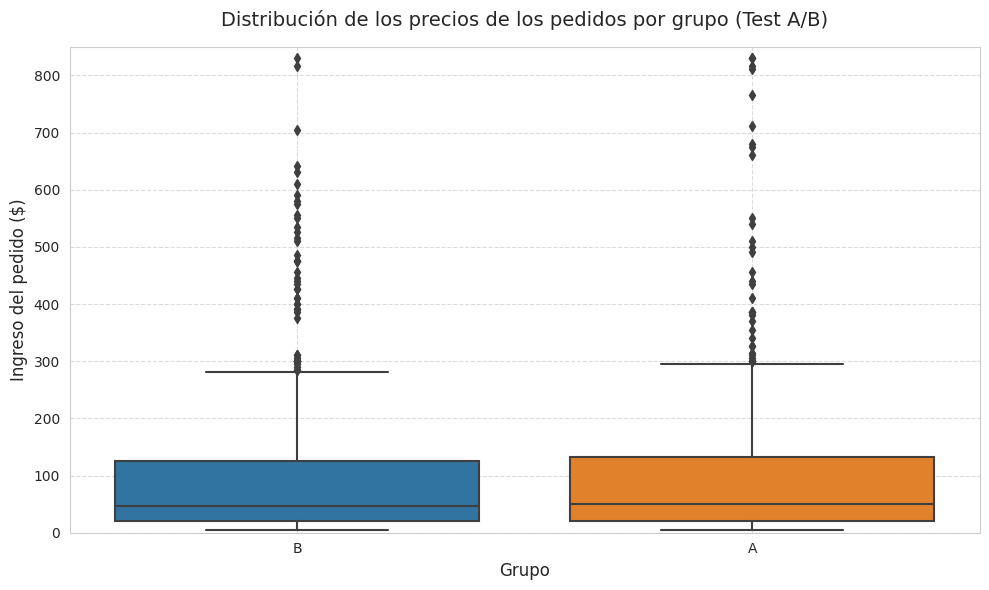

In [37]:
# Configurar estilo de seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Crear boxplots para los precios de los pedidos agrupados por grupo
sns.boxplot(data=ordenes_df_clean, x='group', y='revenue', palette=['#1f77b4', '#ff7f0e'])

# Personalizar el gráfico
plt.title('Distribución de los precios de los pedidos por grupo (Test A/B)', fontsize=14, pad=15)
plt.xlabel('Grupo', fontsize=12)
plt.ylabel('Ingreso del pedido ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.ylim(0, 850)

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

In [38]:
# Filtrar ingresos para el grupo A
ingresos_A = ordenes_df_clean[ordenes_df_clean['group'] == 'A']['revenue']

# Filtrar ingresos para el grupo B
ingresos_B = ordenes_df_clean[ordenes_df_clean['group'] == 'B']['revenue']

In [39]:
# Datos estadísticos del ingreso en el grupo A
ingresos_A.describe()

count     468.000000
mean      113.700855
std       171.372117
min         5.000000
25%        20.300000
50%        50.100000
75%       131.925000
max      1425.800000
Name: revenue, dtype: float64

In [40]:
# Datos estadísticos del ingreso en el grupo B
ingresos_B.describe()

count      548.000000
mean       145.348905
std        868.228227
min          5.100000
25%         20.800000
50%         45.900000
75%        125.200000
max      19920.400000
Name: revenue, dtype: float64

## 2.9 Encontrar la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto.

In [41]:
# Calcular tasa de conversión promedio por grupo
conversion_A = conversion_data[conversion_data['group'] == 'A']['conversion_rate'].mean()
conversion_B = conversion_data[conversion_data['group'] == 'B']['conversion_rate'].mean()

# Calcular número total de visitas y pedidos por grupo
total_visitas_A = conversion_data[conversion_data['group'] == 'A']['visits'].sum()
total_visitas_B = conversion_data[conversion_data['group'] == 'B']['visits'].sum()
total_pedidos_A = conversion_data[conversion_data['group'] == 'A']['num_pedidos'].sum()
total_pedidos_B = conversion_data[conversion_data['group'] == 'B']['num_pedidos'].sum()

In [42]:
# Proporciones de conversión
p_A = total_pedidos_A / total_visitas_A
p_B = total_pedidos_B / total_visitas_B

# Diferencia en proporciones
p_diff = p_B - p_A

In [43]:
# Estimación de la proporción combinada y varianza
p_combined = (total_pedidos_A + total_pedidos_B) / (total_visitas_A + total_visitas_B)
se_diff = ((p_combined * (1 - p_combined) * (1/total_visitas_A + 1/total_visitas_B)) ** 0.5)

# Estadístico z
z_score = p_diff / se_diff

# Valor p (bilateral)
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f"Tasa de conversión promedio - Grupo A: {conversion_A:.4f}")
print(f"Tasa de conversión promedio - Grupo B: {conversion_B:.4f}")
print(f"Diferencia en proporciones (B - A): {p_diff:.4f}")
print(f"Estadístico z: {z_score:.4f}")
print(f"Valor p: {p_value:.4f}")

Tasa de conversión promedio - Grupo A: 0.0307
Tasa de conversión promedio - Grupo B: 0.0353
Diferencia en proporciones (B - A): 0.0041
Estadístico z: 2.2700
Valor p: 0.0232


In [44]:
# Conclusión basada en significancia (α = 0.05)
if p_value < 0.05:
    print("La diferencia en la conversión entre los grupos es estadísticamente significativa.")
else:
    print("La diferencia en la conversión entre los grupos no es estadísticamente significativa.")

La diferencia en la conversión entre los grupos es estadísticamente significativa.


### Observaciones:
- El grupo B tiene una tasa de conversión 13.3% mayor que el grupo A ((3.53-3.07)/3.07 = 0.133), y esta diferencia NO es casualidad (estadísticamente significativa).

### Conjeturas:
- La diferencia significativa del 13.3% en la tasa de conversión sugiere que la variante probada en el grupo B (por ejemplo, cambios en diseño, promociones o funcionalidad) ha sido más efectiva para convertir visitas en pedidos en comparación con la versión actual del grupo A.
- La superioridad sostenida del grupo B podría indicar que los usuarios se han adaptado favorablemente a la variante B a lo largo del tiempo, lo que ha incrementado su disposición a realizar compras, especialmente tras períodos iniciales de ajuste.
- La significancia estadística podría estar impulsada por elementos específicos de la variante B (como una promoción efectiva o una mejora en la experiencia de usuario) que han resonado con los visitantes.

## 2.10 Encontrar la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto.

In [45]:
# Calcular el tamaño promedio de pedido por grupo
mean_A = ingresos_A.mean()
mean_B = ingresos_B.mean()

# Realizar la prueba t de Student (asumiendo varianzas desiguales, prueba t de Welch)
t_stat, p_value = stats.ttest_ind(ingresos_A, ingresos_B, equal_var=False)

print(f"Tamaño promedio de pedido - Grupo A: ${mean_A:.2f}")
print(f"Tamaño promedio de pedido - Grupo B: ${mean_B:.2f}")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Conclusión basada en significancia (α = 0.05)
if p_value < 0.05:
    print("La diferencia en el tamaño promedio de pedido entre los grupos es estadísticamente significativa.")
else:
    print("La diferencia en el tamaño promedio de pedido entre los grupos no es estadísticamente significativa.")

Tamaño promedio de pedido - Grupo A: $113.70
Tamaño promedio de pedido - Grupo B: $145.35
Estadístico t: -0.8345
Valor p: 0.4043
La diferencia en el tamaño promedio de pedido entre los grupos no es estadísticamente significativa.


### Observaciones:
- Se encontró que la diferencia en el tamaño promedio de pedido entre los grupos no es estadísticamente significativa.
- Aún cuando la versión probada por el grupo B atrae a más compradores (tasa d conversión mayor a la del grupo A), el tamaño promedio de la compra no es significativamente superior.
- El tamaño promedio de la compra del grupo B, de 145 USD (mayor a los 113.70 USD del grupo A), podría ser casualidad (no es estadísticamente significativa).

### Conjeturas:
- La falta de significancia estadística en el tamaño promedio de pedido sugiere que, a pesar de la mayor tasa de conversión del grupo B, la variante probada no ha incentivado consistentemente compras de mayor valor, y la diferencia de 31.30 USD podría deberse a variabilidad aleatoria o a outliers.
- El tamaño promedio más alto del grupo B (145 USD) podría estar influenciado por los pedidos atípicos observados (como los 3000 USD y 20000 USD), que no son representativos de la mayoría de las transacciones y no se reflejan como un efecto sostenido de la variante.
- La superioridad en la tasa de conversión del grupo B indica que la variante mejora la atracción de compradores, pero no parece optimizar el valor por transacción, sugiriendo que los cambios podrían estar relacionados con la facilidad de compra más que con el incentivo a gastar más.
- La similitud estadística en los tamaños promedio (113.70 USD vs. 145 USD) podría reflejar que los usuarios de ambos grupos tienen patrones de gasto similares, y la variante B no ha alterado significativamente las preferencias o capacidades de gasto de los clientes.

## 2.11 Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados

In [46]:
# Filtrar ordenes_df_clean para eliminar outliers en revenue (> 830.3 USD)
ordenes_df_filtered = ordenes_df_clean[ordenes_df_clean['revenue'] <= 830.3]

# Contar pedidos por usuario para identificar y filtrar usuarios con > 4 pedidos
pedidos_por_usuario = ordenes_df_filtered.groupby('visitorId')['transactionId'].count().reset_index().rename(columns={'transactionId': 'num_pedidos'})
usuarios_anomalos = pedidos_por_usuario[pedidos_por_usuario['num_pedidos'] > 4]['visitorId']
ordenes_df_filtered = ordenes_df_filtered[~ordenes_df_filtered['visitorId'].isin(usuarios_anomalos)]

In [47]:
# Recalcular conversion_data con datos filtrados
pedidos_por_dia = ordenes_df_filtered.groupby(['date', 'group'])['transactionId'].count().reset_index()
conversion_data_filtered = pd.merge(visitas_df, pedidos_por_dia, on=['date', 'group'], how='left')
conversion_data_filtered['num_pedidos'] = conversion_data_filtered['transactionId'].fillna(0)
conversion_data_filtered['conversion_rate'] = conversion_data_filtered['num_pedidos'] / conversion_data_filtered['visits']

# Calcular tasa de conversión promedio por grupo con datos filtrados
conversion_A = conversion_data_filtered[conversion_data_filtered['group'] == 'A']['conversion_rate'].mean()
conversion_B = conversion_data_filtered[conversion_data_filtered['group'] == 'B']['conversion_rate'].mean()

In [48]:
# Calcular número total de visitas y pedidos por grupo con datos filtrados
total_visitas_A = conversion_data_filtered[conversion_data_filtered['group'] == 'A']['visits'].sum()
total_visitas_B = conversion_data_filtered[conversion_data_filtered['group'] == 'B']['visits'].sum()
total_pedidos_A = conversion_data_filtered[conversion_data_filtered['group'] == 'A']['num_pedidos'].sum()
total_pedidos_B = conversion_data_filtered[conversion_data_filtered['group'] == 'B']['num_pedidos'].sum()

# Proporciones de conversión
p_A = total_pedidos_A / total_visitas_A
p_B = total_pedidos_B / total_visitas_B

In [49]:
# Diferencia en proporciones
p_diff = p_B - p_A

# Estimación de la proporción combinada y varianza
p_combined = (total_pedidos_A + total_pedidos_B) / (total_visitas_A + total_visitas_B)
se_diff = ((p_combined * (1 - p_combined) * (1/total_visitas_A + 1/total_visitas_B)) ** 0.5)

# Estadístico z
z_score = p_diff / se_diff

In [50]:
# Valor p (bilateral)
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f"Tasa de conversión promedio - Grupo A (filtrado): {conversion_A:.4f}")
print(f"Tasa de conversión promedio - Grupo B (filtrado): {conversion_B:.4f}")
print(f"Diferencia en proporciones (B - A): {p_diff:.4f}")
print(f"Estadístico z: {z_score:.4f}")
print(f"Valor p: {p_value:.4f}")

# Conclusión basada en significancia (α = 0.05)
if p_value < 0.05:
    print("La diferencia en la conversión entre los grupos es estadísticamente significativa.")
else:
    print("La diferencia en la conversión entre los grupos no es estadísticamente significativa.")

Tasa de conversión promedio - Grupo A (filtrado): 0.0256
Tasa de conversión promedio - Grupo B (filtrado): 0.0302
Diferencia en proporciones (B - A): 0.0040
Estadístico z: 2.4336
Valor p: 0.0149
La diferencia en la conversión entre los grupos es estadísticamente significativa.


### Observaciones:
- La diferencia en la conversión entre los grupos sigue siendo estadísticamente significativa, luego de remover los datos anómalos.
- La tasa de conversión promedio del grupo B, es significativamente superior a la tasa de conversión promedio del grupo A.

### Conjeturas:
- La persistencia de la significancia estadística tras eliminar outliers sugiere que la variante probada en el grupo B tiene un impacto real y positivo en la conversión, posiblemente debido a mejoras en la interfaz, promociones o facilidad de compra que atraen a más usuarios típicos.
- La superioridad del grupo B en la tasa de conversión, incluso sin usuarios anómalos (con más de 4 pedidos o revenue > 830.3 USD), indica que la variante es efectiva para la mayoría de los usuarios (con 1-4 pedidos), reflejando una adaptación generalizada a los cambios implementados.

## 2.12 Encontrar la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados.

In [51]:
# Filtrar ingresos para el grupo A y B desde los datos filtrados
ingresos_A_filtrados = ordenes_df_filtered[ordenes_df_filtered['group'] == 'A']['revenue']
ingresos_B_filtrados = ordenes_df_filtered[ordenes_df_filtered['group'] == 'B']['revenue']

In [52]:
ingresos_A_filtrados.describe()

count    463.000000
mean     103.163067
std      137.645141
min        5.000000
25%       20.300000
50%       50.100000
75%      128.000000
max      830.300000
Name: revenue, dtype: float64

In [53]:
ingresos_B_filtrados.describe()

count    544.000000
mean      99.943566
std      131.020720
min        5.100000
25%       20.800000
50%       45.700000
75%      120.225000
max      830.300000
Name: revenue, dtype: float64

In [54]:
# Calcular el tamaño promedio de pedido por grupo
mean_A = ingresos_A_filtrados.mean()
mean_B = ingresos_B_filtrados.mean()

In [56]:
# Realizar la prueba t de Student (asumiendo varianzas desiguales, prueba t de Welch)
t_stat, p_value = stats.ttest_ind(ingresos_A, ingresos_B, equal_var=False)

print(f"Tamaño promedio de pedido - Grupo A (filtrado): ${mean_A:.2f}")
print(f"Tamaño promedio de pedido - Grupo B (filtrado): ${mean_B:.2f}")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Conclusión basada en significancia (α = 0.05)
if p_value < 0.05:
    print("La diferencia en el tamaño promedio de pedido entre los grupos es estadísticamente significativa.")
else:
    print("La diferencia en el tamaño promedio de pedido entre los grupos no es estadísticamente significativa.")

Tamaño promedio de pedido - Grupo A (filtrado): $103.16
Tamaño promedio de pedido - Grupo B (filtrado): $99.94
Estadístico t: -0.8345
Valor p: 0.4043
La diferencia en el tamaño promedio de pedido entre los grupos no es estadísticamente significativa.


### Observaciones:
- Nuevamente, se encontró que la diferencia en el tamaño promedio de pedido entre los grupos no es estadísticamente significativa.
- De hecho, al filtrar los datos (eliminar los datos anómalos), el desempeño del grupo B (100 USD tamaño promedio) fue ligeramente inferior al desempeño del grupo A (103 USD tamaño promedio), pero que puedo ser por casualidad (no significativo).

### Conjeturas:
- El desempeño del grupo B (100 USD) por debajo del grupo A (103 USD), tras eliminar outliers sugiere que la variante probada en el grupo B, podría indicar un efecto neutro en el tamaño promedio de pedido, posiblemente porque los cambios no incentivan compras de mayor valor.
- La cercanía de los tamaños promedio (100 USD vs. 103 USD) indica que los usuarios de ambos grupos tienen comportamientos de compra similares tras filtrar, y la variante B no ha alterado significativamente las preferencias o capacidades de gasto de los clientes.
- La superioridad del grupo B en la tasa de conversión (observada previamente) contrasta con su menor tamaño promedio de pedido, sugiriendo que la variante optimiza la atracción de compradores, pero no el valor por transacción, posiblemente debido a un diseño que prioriza la cantidad sobre el monto.

# 3 Toma de decisión basada en los resultados de la prueba

### La prueba ha demostrado que la versión modificada de la tienda en línea (grupo B), atrajo consistenetemente más compradores que la versión actual (grupo A), con una tasa de conversión del 3.02% que represnta un incremento del 18% con respecto a la tasa de conversión actual. Aún cuando el tamaño promedio de la compra de la versión alternativa (grupo B) es prácticamente igual a la versión actual, a largo plazo, la versión alternativa atraerá más ingreso a la tienda debido a su tasa de conversión superior, que de hecho, se corrobora con la comparación del ingreso acumulado. Por lo tanto, la prueba puede considerarse un ÉXITO, detenerse aquí e implementarla; en caso de querer un tamaño promedio de la compra superior al actual, habría que optar por probar hipótesis diferente.